In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls '/content/drive/MyDrive/nlp_assignment_sentimentdata'

test_preprocessed.csv  train_preprocessed.csv


In [3]:
import pandas as pd

train_path = '/content/drive/MyDrive/nlp_assignment_sentimentdata/train_preprocessed.csv'
test_path = '/content/drive/MyDrive/nlp_assignment_sentimentdata/test_preprocessed.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.head())
print(test_df.head())

                                               Tweet   Sentiment  \
0  @atRachelGilmore Wow...you must not know the d...  Strong_Neg   
1  @JacquiDelaney @brianlilley Police told Public...  Strong_Pos   
2  please take note on the people who were postin...  Strong_Pos   
3  âSlash The Tires, Arrest The Driversâ: Har...    Mild_Neg   
4  @RayanKReal @thevivafrei @JustinTrudeau that l...  Strong_Pos   

                                         Clean_Tweet  Label  
0  Wow...you must not know the difference between...      3  
1  Police told Public Safety Minister Marco Mendi...      4  
2  please take note on the people who were postin...      4  
3  âSlash The Tires, Arrest The Driversâ Harvard ...      0  
4  that looks like a mostly peaceful protest, not...      4  
                                               Tweet   Sentiment  \
0  The #RCMP started sharing names of individuals...    Mild_Pos   
1  Whoa, Canada: Police criminalize food, fuel do...  Strong_Pos   
2  Just closed 

In [4]:
def tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

In [5]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove.6B

def load_glove(file_path):
    embeddings = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = list(map(float, parts[1:]))
            embeddings[word] = vector
    return embeddings

glove_embeddings = load_glove('glove.6B/glove.6B.100d.txt')
print(f"GloVe vectors loaded: {len(glove_embeddings)}")

GloVe vectors loaded: 400000


In [6]:
import re
import numpy as np

# Step 1: Safe tokenization
def tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

# Step 2: Average GloVe vector for one tweet
def avg_glove_vector(text, embeddings, dim=100):
    tokens = tokenize(text)
    vectors = [embeddings[word] for word in tokens if word in embeddings]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# Step 3: Clean missing values (if any)
train_df['Clean_Tweet'] = train_df['Clean_Tweet'].fillna('')
test_df['Clean_Tweet'] = test_df['Clean_Tweet'].fillna('')

# Step 4: Generate feature arrays
X_train_glove = np.array([avg_glove_vector(t, glove_embeddings) for t in train_df['Clean_Tweet']])
X_test_glove = np.array([avg_glove_vector(t, glove_embeddings) for t in test_df['Clean_Tweet']])

print("Embedding generation complete")
print("X_train_glove shape:", X_train_glove.shape)
print("X_test_glove shape:", X_test_glove.shape)

Embedding generation complete
X_train_glove shape: (406198, 100)
X_test_glove shape: (45134, 100)


Evaluation Metrics:
Accuracy: 0.6007
F1 Score for class 0: 0.0805
F1 Score for class 1: 0.0107
F1 Score for class 2: 0.4224
F1 Score for class 3: 0.4295
F1 Score for class 4: 0.7643
AUC Score: 0.7716
Training Time: 159.52 seconds


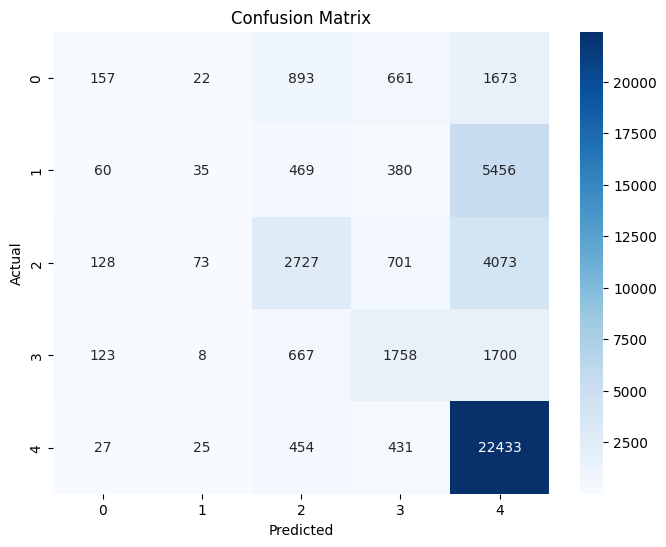

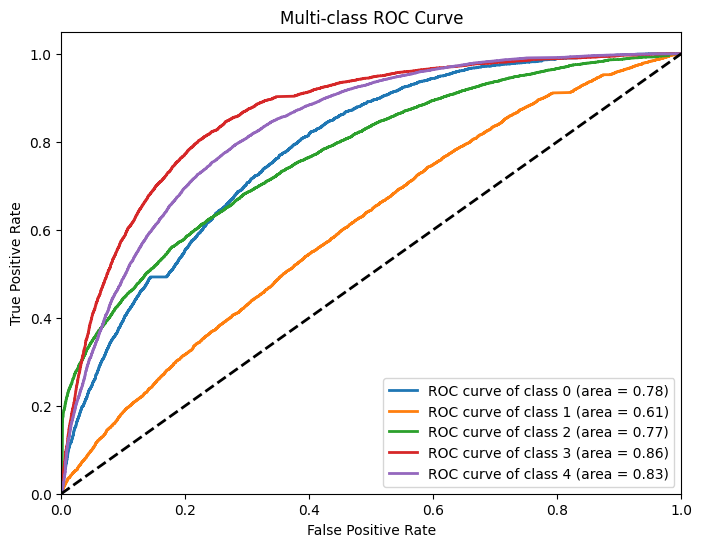

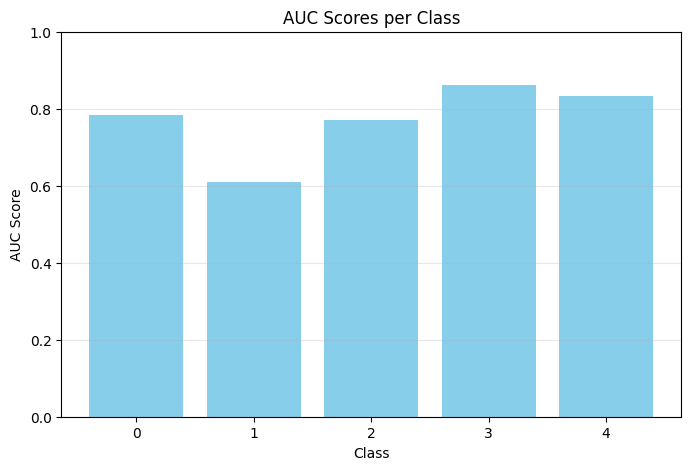

In [18]:
# Step 1: Make sure labels are defined
y_train = train_df['Label']
y_test = test_df['Label']

# Step 2: Use subset for faster training
train_subset = train_df.sample(n=20000, random_state=42)
X_train_sub = np.array([avg_glove_vector(t, glove_embeddings) for t in train_subset['Clean_Tweet']])
y_train_sub = train_subset['Label']

# Step 3: Train SVM
import time  # Add this at the top of your code if not already imported

start_time = time.time()  # Start timer
from sklearn.svm import SVC
svm = SVC(kernel='linear', C=1, probability=True)
svm.fit(X_train_sub, y_train_sub)
training_time = time.time() - start_time  # End timer

# Step 4: Predict
y_pred = svm.predict(X_test_glove)
y_proba = svm.predict_proba(X_test_glove)

# Step 5: Evaluate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_test is defined here too
y_test = test_df['Label']

acc = accuracy_score(y_test, y_pred)
f1_per_class = f1_score(y_test, y_pred, average=None)
classes = np.unique(y_train)  # Should be something like ['negative', 'positive'] or [0,1]
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
auc_score = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')

print("Evaluation Metrics:")
print(f"Accuracy: {acc:.4f}")
for cls, f1_val in zip(classes, f1_per_class):
    print(f"F1 Score for class {cls}: {f1_val:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"Training Time: {training_time:.2f} seconds")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---- ROC Curve Plotting ----
fpr = dict()
tpr = dict()
roc_auc = dict()
classes = np.unique(y_train)

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {cls} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Plot AUC scores as a bar chart
plt.figure(figsize=(8, 5))
plt.bar([str(cls) for cls in classes], [roc_auc[i] for i in range(len(classes))], color='skyblue')
plt.xlabel('Class')
plt.ylabel('AUC Score')
plt.title('AUC Scores per Class')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.show()

